<a href="https://colab.research.google.com/github/NahomiHM/Procesos-estocasticos/blob/main/Caminata_aleatoris_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Caminata Aleatoria
Escribir un código que implemente una camita aleatoria 1D, con probabilidad $p$ de moverse a la derecha y probabilidad $q$  de moverse a la izquierda, tal que $p + q = 1$   
Sabiendo que $p + q = 1$, entonces  $q = 1 - p$.

La posición en el paso $N$ está dada por la suma de los pasos individuales $S_i$:
$$X_N = \sum_{i=1}^{N} S_i$$

### Propiedades Teóricas
El valor esperado (promedio teórico) de la posición final después de $N$ pasos es:
$$E[X_N] = N \cdot (p - q) = N \cdot (2p - 1)$$

* Si $p = 0.5$, el promedio es 0 (Caminata simétrica).
* Si $p \neq 0.5$, existe un desplazamiento o "drift".




In [ ]:
import random as r #Importamos la libreria necesaria para colocar numeros aleatorios
import matplotlib.pyplot as plt #Importamos la libreria necesaria para graficar

Revisamos que la libreria este funcionando correctamente

In [ ]:
r.random() #genera un numero aletario

0.8067892419718157

Empezamos generando una funcion para que guarde $p$ y $q$


In [ ]:
def caminata(Probabilidad, N ):
  x = 0 # X sera mi posicion inicial de la funcion
  p = [] #colocamos una lista vacia para guardar los valores
  N = 20 #cuantos valores queremos que tome
  Probabilidad = .5  #Probabilidad de que se mueva a la
  for i in range(N):
    dice = r.random() #generamos un numero aleatorio
    if dice <= Probabilidad: #si el numero aleatorio es menor o igual a la probabilidad
      x += 1 #se mueve a la derecha
    else: #sino
      x -= 1 #se mueve a la izquierda
    p.append(x) #guardamos el valor de x en la lista p
  return p #retornamos la lista p


Ya que tenemos la lista aleatoria vamos a graficarla e imprimir los datos

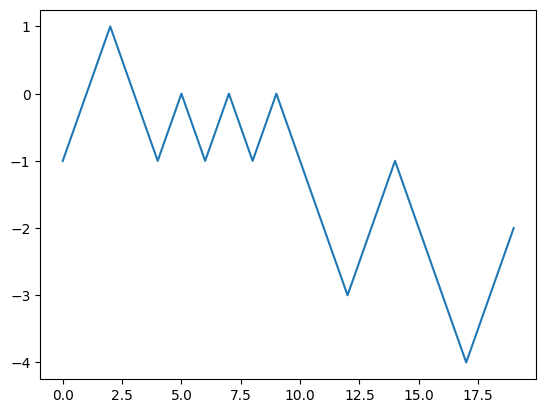

In [ ]:
#graficamos la funcion
plt.plot( caminata( .5, 20) )
plt.show()

Probaremos el codigo con tres casos distintos para ver el comportamiento cuando a $p$ se le asignan valores distintos
Ya contamos con $p= .5$

$p = 0 .7$

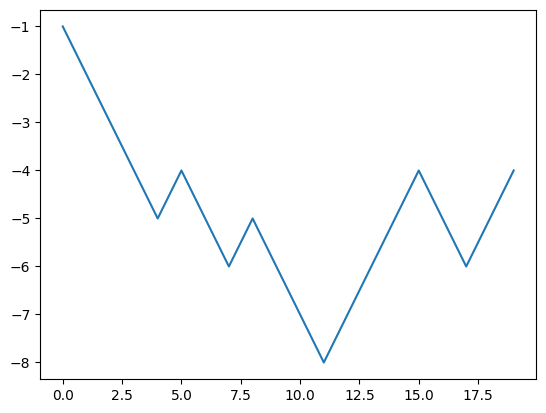

In [ ]:
def caminataconprobabilidad7(Probabilidad, N ):
  x = 0 # X sera mi posicion inicial de la funcion
  p = [] #colocamos una lista vacia para guardar los valores
  N = 20 #cuantos valores queremos que tome
  Probabilidad = .7  #Probabilidad de que se mueva a la
  for i in range(N):
    dice = r.random() #generamos un numero aleatorio
    if dice <= Probabilidad: #si el numero aleatorio es menor o igual a la probabilidad
      x += 1 #se mueve a la derecha
    else: #sino
      x -= 1 #se mueve a la izquierda
    p.append(x) #guardamos el valor de x en la lista p
  return p #retornamos la lista p
  #graficamos la funcion
plt.plot(caminata( .7, 20) )
plt.show()

$p = .9 $

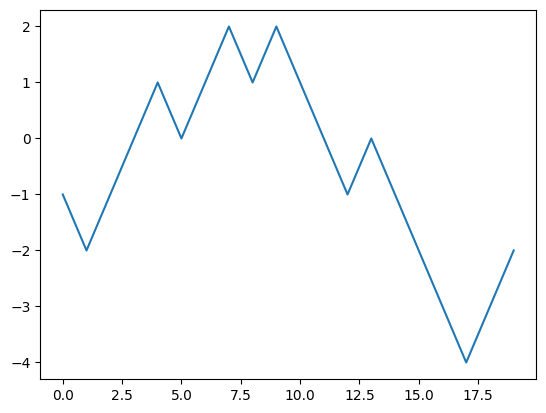

In [ ]:
def caminataconprobabilidad9(Probabilidad, N ):
  x = 0 # X sera mi posicion inicial de la funcion
  p = [] #colocamos una lista vacia para guardar los valores
  N = 20 #cuantos valores queremos que tome
  Probabilidad = .9  #Probabilidad de que se mueva a la
  for i in range(N):
    dice = r.random() #generamos un numero aleatorio
    if dice <= Probabilidad: #si el numero aleatorio es menor o igual a la probabilidad
      x += 1 #se mueve a la derecha
      print ("avanza    :", x )
    else: #sino
      x -= 1 #se mueve a la izquierda
      print ("retrocede :", x)
    p.append(x) #guardamos el valor de x en la lista p
  return p #retornamos la lista p
  #graficamos la funcion
plt.plot( caminata( .9, 20) )
plt.show()

Para saber cual es la posicion promedio final despues de muchos pasos $$E[X] \approx \frac{1}{M} \sum_{j=1}^{M} x_{final, j}$$


In [ ]:
n_pasos = 1000      # Longitud de la caminata
n_simulaciones =10000 #  veces repetimos el experimento
p = 0.5             # Probabilidad

# Listas para guardar los resultados del experimento
todas_las_trayectorias = []
posiciones_finales = []

for sim in range(n_simulaciones):
    # Llamamos a la funcion
    recorrido = caminata(p, n_pasos)

    # Guardamos los datos para analizar luego
    todas_las_trayectorias.append(recorrido)
    posiciones_finales.append(recorrido[-1])


# Calculamos el promedio sumando todo y dividiendo por la cantidad
promedio_final_observado = sum(posiciones_finales) / len(posiciones_finales)

# Calculamos el valor teórico esperado: N * (2p - 1)
valor_teorico = n_pasos * (2 * p - 1) # el valor esperado

print(f"Probabilidad  {p}")
print(f" Promedio simulada: {promedio_final_observado:.2f}")
print(f"Teórica esperada:  {valor_teorico:.2f}")

# Validación automática
if abs(promedio_final_observado - valor_teorico) < (n_pasos * 0.05):
    print("La simulación coincide con la teoría.")
else:
    print("Se requiere más simulaciones para converger.")

Probabilidad  0.5
 Promedio simulada: -0.01
Teórica esperada:  0.00
La simulación coincide con la teoría.


Con los resultados obtenidos en la simulacion se puede ver que el promedio se va manteninedo cerca del cero

**¿Que puede pasar con $p$ para que vuelva al orige?**



Para que la partícula no se vaya al infinito y se mantenga oscilando cerca del punto de inicio (0) la probabilidad de ir a la derecha y a la izquierda debe ser igual.

Si $p$ es la probabilidad de ir a la derecha:
* Si $p = 0.5$, la partícula regresa.
* Si $p \neq 0.5$, la partícula se aleja.

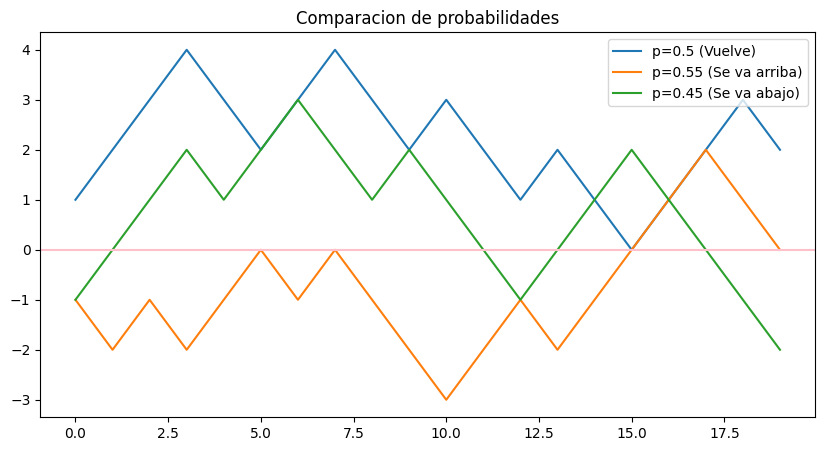

In [ ]:
pasos = 1000

# Caso Equilibrado (p=0.5)
camino_centro = caminata(0.5, pasos)

# Caso con ventaja a la derecha (p=0.55)
camino_arriba = caminata(0.55, pasos)

# Caso con ventaja a la izquierda (p=0.45)
camino_abajo = caminata(0.45, pasos)

plt.figure(figsize=(10, 5))

# Graficamos una por una
plt.plot(camino_centro, label="p=0.5 (Vuelve)")
plt.plot(camino_arriba, label="p=0.55 (Se va arriba)")
plt.plot(camino_abajo, label="p=0.45 (Se va abajo)")

# Ponemos una linea en el 0 para referencia
plt.axhline(0, color='pink')

plt.legend()
plt.title("Comparacion de probabilidades")
plt.show()

Podemos observar con esta grafica que para que vuelva al origen esta debe de esta con $p = .5$